/tmp/ipykernel_51398/2015395014.py:6: DtypeWarning: Columns (7,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  outdoor_temp = pd.read_csv('./campaign_data/outdoor_temp.csv', dtype={'gps_lat_out': str, 'gps_long_out': str})
/tmp/ipykernel_51398/2015395014.py:7: DtypeWarning: Columns (7,8,11,12,13,25,33,35) have mixed types. Specify dtype option on import or set low_memory=False.
  indoor_temp = pd.read_csv('./campaign_data/indoor_temp.csv', dtype={'gps_lat_in': str, 'gps_long_in': str})
/opt/conda/lib/python3.11/site-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname F identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


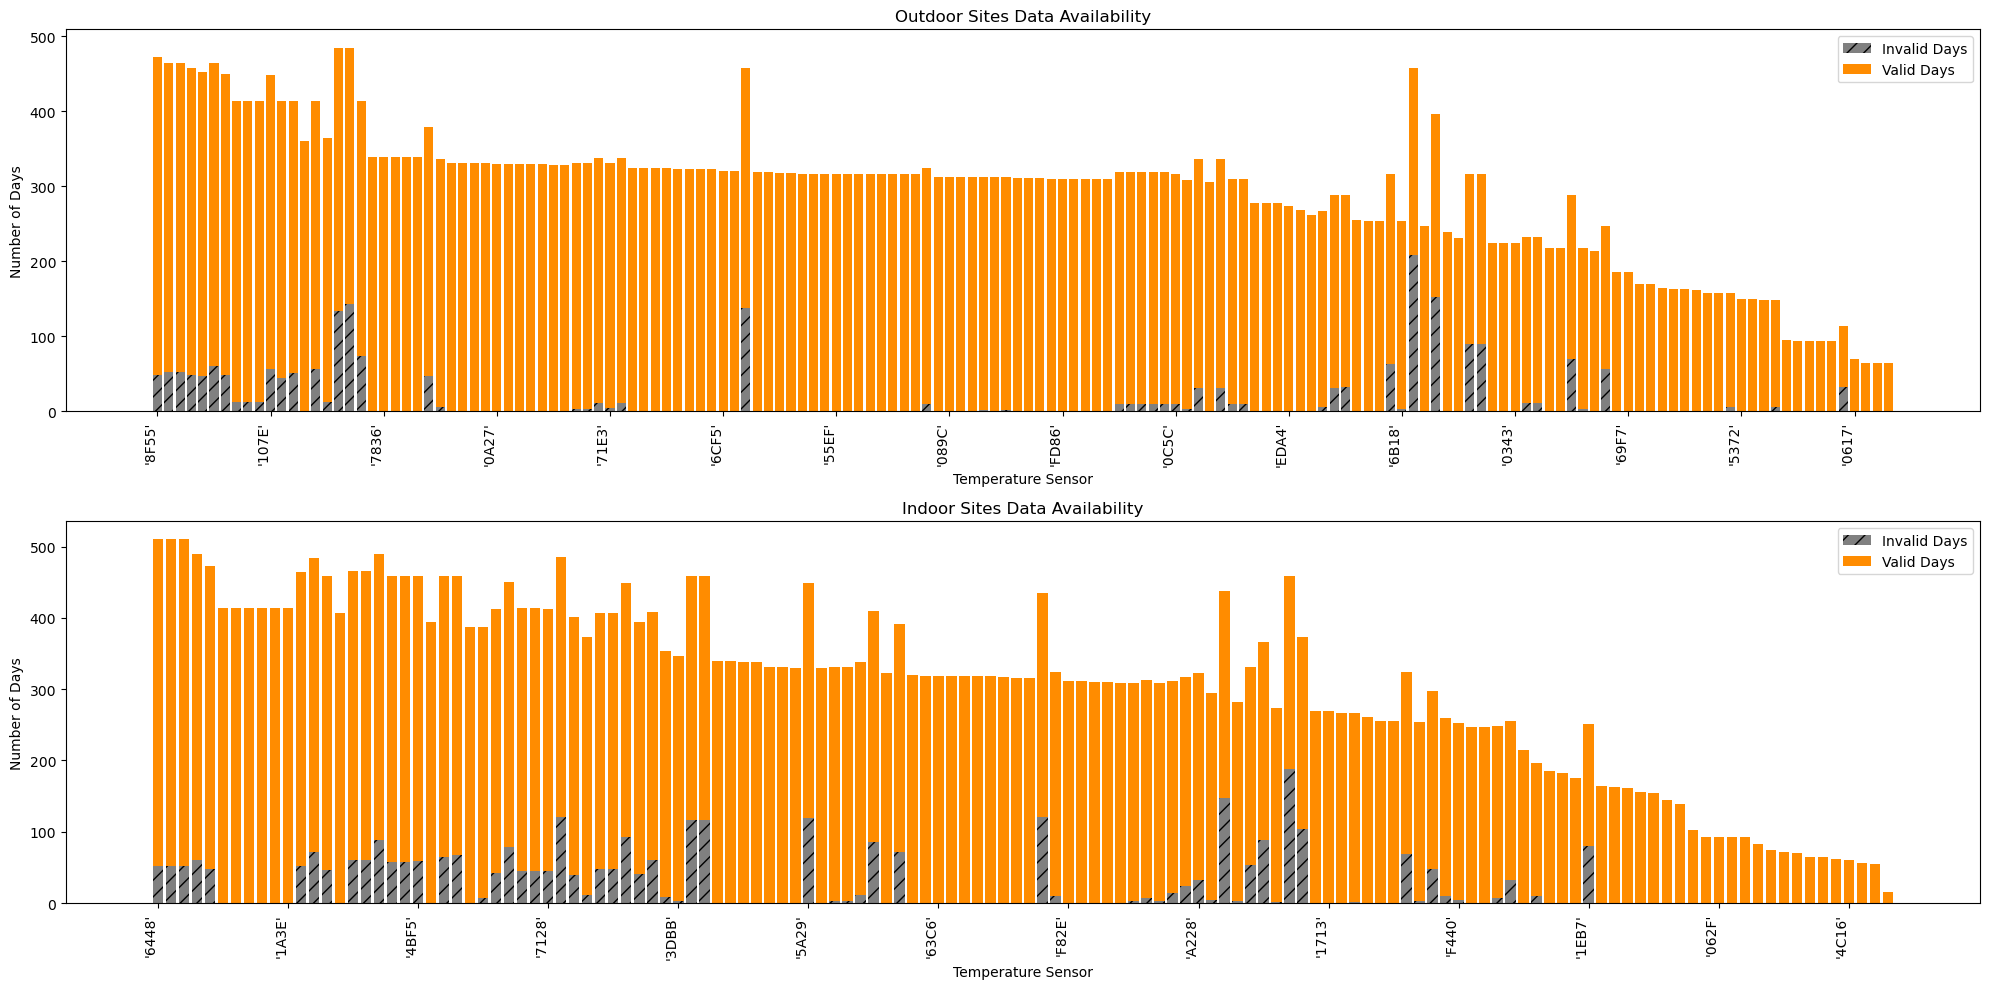

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the outdoor and indoor temperature data
outdoor_temp = pd.read_csv('./campaign_data/outdoor_temp.csv', dtype={'gps_lat_out': str, 'gps_long_out': str})
indoor_temp = pd.read_csv('./campaign_data/indoor_temp.csv', dtype={'gps_lat_in': str, 'gps_long_in': str})

# Convert 'Date/Time' to datetime format
outdoor_temp['Date/Time'] = pd.to_datetime(outdoor_temp['Date/Time'])
indoor_temp['Date/Time'] = pd.to_datetime(indoor_temp['Date/Time'])

# Set 'Date/Time' as the index
outdoor_temp.set_index('Date/Time', inplace=True)
indoor_temp.set_index('Date/Time', inplace=True)

# Add a column to indicate valid data
outdoor_temp['valid'] = 1
indoor_temp['valid'] = 1

# Resample to daily frequency and count the number of valid data points per day
outdoor_daily = outdoor_temp.groupby('sensor_id_outdoor_temp').resample('D')['valid'].sum().reset_index()
indoor_daily = indoor_temp.groupby('sensor_id_indoor_temp').resample('D')['valid'].sum().reset_index()

# Calculate the total number of days in the deployment period for each sensor
outdoor_deployment = outdoor_daily.groupby('sensor_id_outdoor_temp').agg(
    start_date=('Date/Time', 'min'),
    end_date=('Date/Time', 'max')
)
outdoor_deployment['total_days'] = (outdoor_deployment['end_date'] - outdoor_deployment['start_date']).dt.days + 1

indoor_deployment = indoor_daily.groupby('sensor_id_indoor_temp').agg(
    start_date=('Date/Time', 'min'),
    end_date=('Date/Time', 'max')
)
indoor_deployment['total_days'] = (indoor_deployment['end_date'] - indoor_deployment['start_date']).dt.days + 1

# Calculate the number of valid days
outdoor_valid_days = outdoor_daily[outdoor_daily['valid'] > 0].groupby('sensor_id_outdoor_temp').size()
indoor_valid_days = indoor_daily[indoor_daily['valid'] > 0].groupby('sensor_id_indoor_temp').size()

# Combine the results into a single DataFrame for plotting
outdoor_results = outdoor_deployment.join(outdoor_valid_days.rename('valid_days')).fillna(0)
outdoor_results['invalid_days'] = outdoor_results['total_days'] - outdoor_results['valid_days']
outdoor_results.sort_values(by='valid_days', ascending=False, inplace=True)

indoor_results = indoor_deployment.join(indoor_valid_days.rename('valid_days')).fillna(0)
indoor_results['invalid_days'] = indoor_results['total_days'] - indoor_results['valid_days']
indoor_results.sort_values(by='valid_days', ascending=False, inplace=True)

# Plot the results
fig, axes = plt.subplots(2, 1, figsize=(20, 10))

# Plot outdoor sites
axes[0].bar(outdoor_results.index, outdoor_results['invalid_days'], color='grey', label='Invalid Days', hatch='//')
axes[0].bar(outdoor_results.index, outdoor_results['valid_days'], bottom=outdoor_results['invalid_days'], color='darkorange', label='Valid Days')
axes[0].set_ylabel('Number of Days')
axes[0].set_title('Outdoor Sites Data Availability')
axes[0].legend()
axes[0].set_xlabel('Temperature Sensor')
axes[0].set_xticks(np.arange(0, len(outdoor_results), step=10))
axes[0].set_xticklabels(outdoor_results.index[::10], rotation=90, ha='right')

# Plot indoor sites
axes[1].bar(indoor_results.index, indoor_results['invalid_days'], color='grey', label='Invalid Days', hatch='//')
axes[1].bar(indoor_results.index, indoor_results['valid_days'], bottom=indoor_results['invalid_days'], color='darkorange', label='Valid Days')
axes[1].set_ylabel('Number of Days')
axes[1].set_title('Indoor Sites Data Availability')
axes[1].legend()
axes[1].set_xlabel('Temperature Sensor')
axes[1].set_xticks(np.arange(0, len(indoor_results), step=10))
axes[1].set_xticklabels(indoor_results.index[::10], rotation=90, ha='right')

plt.tight_layout()
plt.savefig('data_availability_by_sensor_ordered.png', bbox_inches='tight')
plt.show()


/tmp/ipykernel_51398/2577772374.py:6: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  outdoor_hum = pd.read_csv('./campaign_data/outdoor_hum.csv', dtype={'gps_lat_out': str, 'gps_long_out': str})
/tmp/ipykernel_51398/2577772374.py:7: DtypeWarning: Columns (8,12) have mixed types. Specify dtype option on import or set low_memory=False.
  indoor_hum = pd.read_csv('./campaign_data/indoor_hum.csv', dtype={'gps_lat_in': str, 'gps_long_in': str})


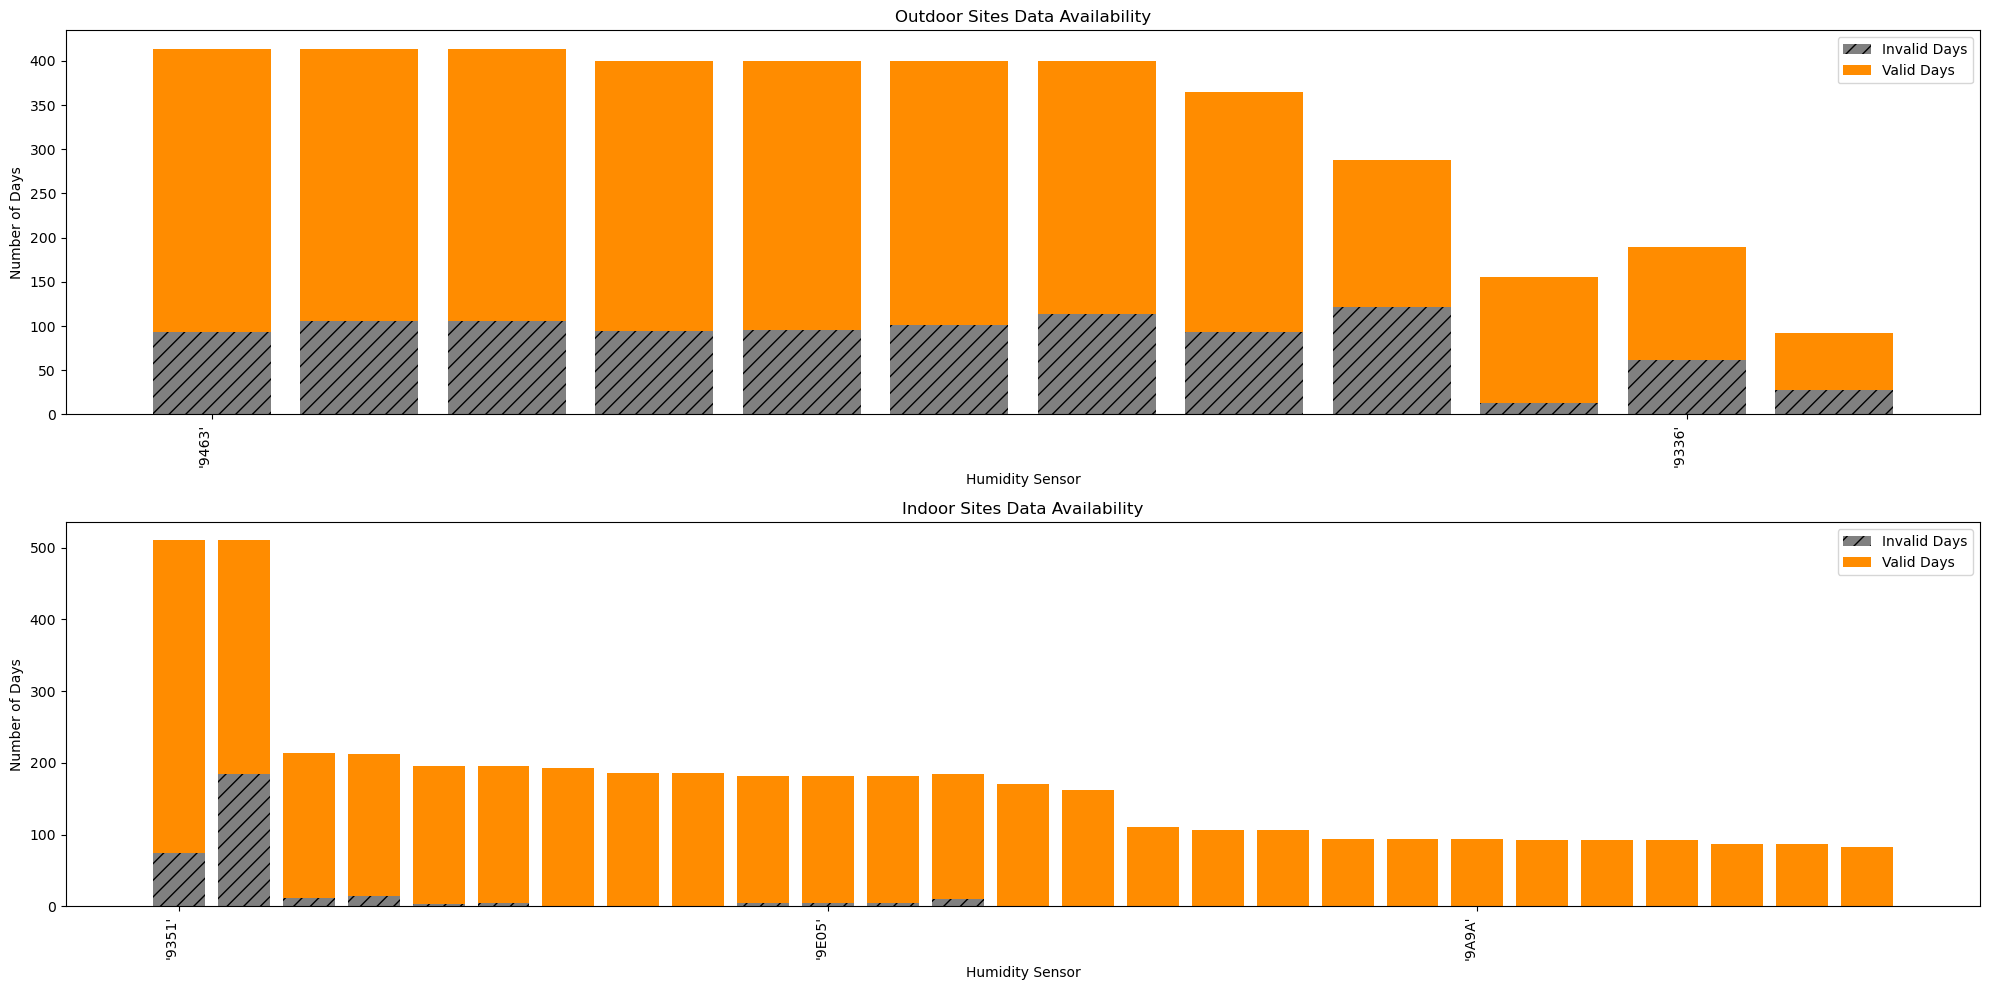

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the outdoor and indoor humerature data
outdoor_hum = pd.read_csv('./campaign_data/outdoor_hum.csv', dtype={'gps_lat_out': str, 'gps_long_out': str})
indoor_hum = pd.read_csv('./campaign_data/indoor_hum.csv', dtype={'gps_lat_in': str, 'gps_long_in': str})

# Convert 'Date/Time' to datetime format
outdoor_hum['Date/Time'] = pd.to_datetime(outdoor_hum['Date/Time'])
indoor_hum['Date/Time'] = pd.to_datetime(indoor_hum['Date/Time'])

# Set 'Date/Time' as the index
outdoor_hum.set_index('Date/Time', inplace=True)
indoor_hum.set_index('Date/Time', inplace=True)

# Add a column to indicate valid data
outdoor_hum['valid'] = 1
indoor_hum['valid'] = 1

# Resample to daily frequency and count the number of valid data points per day
outdoor_daily = outdoor_hum.groupby('sensor_id_outdoor_hum').resample('D')['valid'].sum().reset_index()
indoor_daily = indoor_hum.groupby('sensor_id_indoor_hum').resample('D')['valid'].sum().reset_index()

# Calculate the total number of days in the deployment period for each sensor
outdoor_deployment = outdoor_daily.groupby('sensor_id_outdoor_hum').agg(
    start_date=('Date/Time', 'min'),
    end_date=('Date/Time', 'max')
)
outdoor_deployment['total_days'] = (outdoor_deployment['end_date'] - outdoor_deployment['start_date']).dt.days + 1

indoor_deployment = indoor_daily.groupby('sensor_id_indoor_hum').agg(
    start_date=('Date/Time', 'min'),
    end_date=('Date/Time', 'max')
)
indoor_deployment['total_days'] = (indoor_deployment['end_date'] - indoor_deployment['start_date']).dt.days + 1

# Calculate the number of valid days
outdoor_valid_days = outdoor_daily[outdoor_daily['valid'] > 0].groupby('sensor_id_outdoor_hum').size()
indoor_valid_days = indoor_daily[indoor_daily['valid'] > 0].groupby('sensor_id_indoor_hum').size()

# Combine the results into a single DataFrame for plotting
outdoor_results = outdoor_deployment.join(outdoor_valid_days.rename('valid_days')).fillna(0)
outdoor_results['invalid_days'] = outdoor_results['total_days'] - outdoor_results['valid_days']
outdoor_results.sort_values(by='valid_days', ascending=False, inplace=True)

indoor_results = indoor_deployment.join(indoor_valid_days.rename('valid_days')).fillna(0)
indoor_results['invalid_days'] = indoor_results['total_days'] - indoor_results['valid_days']
indoor_results.sort_values(by='valid_days', ascending=False, inplace=True)

# Plot the results
fig, axes = plt.subplots(2, 1, figsize=(20, 10))

# Plot outdoor sites
axes[0].bar(outdoor_results.index, outdoor_results['invalid_days'], color='grey', label='Invalid Days', hatch='//')
axes[0].bar(outdoor_results.index, outdoor_results['valid_days'], bottom=outdoor_results['invalid_days'], color='darkorange', label='Valid Days')
axes[0].set_ylabel('Number of Days')
axes[0].set_title('Outdoor Sites Data Availability')
axes[0].legend()
axes[0].set_xlabel('Humidity Sensor')
axes[0].set_xticks(np.arange(0, len(outdoor_results), step=10))
axes[0].set_xticklabels(outdoor_results.index[::10], rotation=90, ha='right')

# Plot indoor sites
axes[1].bar(indoor_results.index, indoor_results['invalid_days'], color='grey', label='Invalid Days', hatch='//')
axes[1].bar(indoor_results.index, indoor_results['valid_days'], bottom=indoor_results['invalid_days'], color='darkorange', label='Valid Days')
axes[1].set_ylabel('Number of Days')
axes[1].set_title('Indoor Sites Data Availability')
axes[1].legend()
axes[1].set_xlabel('Humidity Sensor')
axes[1].set_xticks(np.arange(0, len(indoor_results), step=10))
axes[1].set_xticklabels(indoor_results.index[::10], rotation=90, ha='right')

plt.tight_layout()
plt.savefig('hum_data_availability_by_sensor_ordered.png', bbox_inches='tight')
plt.show()
